# 🚀 Módulo 15: Deploy, Governança e Ética em Modelos de ML

## Objetivos deste módulo

Ao final deste notebook você será capaz de:

1. **Serializar e desserializar** modelos de ML com `joblib` e `pickle`
2. **Construir pipelines completos** com `ColumnTransformer` e `Pipeline` do scikit-learn
3. **Calcular e interpretar o PSI** (Population Stability Index) para detectar data drift
4. **Analisar fairness** e viés por subgrupo demografico
5. **Criar um Model Card** completo para documentação e governança
6. **Aplicar responsabilidades éticas** no ciclo de vida do modelo

---

> **Contexto:** Um modelo de ML não termina no treinamento. O verdadeiro desafio começa no **deploy**:
> garantir que ele funcione corretamente em produção, que seja monitorado, que não discrimine
> grupos vulneráveis e que seja documentado de forma transparente.


## 2. Teoria

### 2.1 O Ciclo de Vida do Modelo
Desenvolvimento → Validação → Deploy → Monitoramento → Retreinamento

### 2.2 Population Stability Index (PSI)
Detecta se a distribuição dos dados de entrada mudou (drift):
$$PSI = \sum_{i=1}^{n}\left(\%A_i - \%E_i\right) \cdot \ln\left(\frac{\%A_i}{\%E_i}\right)$$
| PSI | Interpretação |
|-----|---------------|
| < 0.10 | Estável — sem ação necessária |
| 0.10 – 0.20 | Alerta — investigar |
| > 0.20 | Instável — retreinar ou revisar |

### 2.3 Model Card (Documentação)
Documentar o modelo protege a organização e os usuários:
- **Propósito**: para que serve o modelo?
- **Dados**: o que foi usado para treino e validação?
- **Performance**: métricas gerais e por subgrupo
- **Limitações**: onde o modelo não deve ser usado?
- **Considerações éticas**: quais grupos podem ser afetados?

### 2.4 Responsabilidades Éticas
- **Fairness**: o modelo discrimina subgrupos?
- **Transparência**: decisões podem ser explicadas?
- **Privacidade**: dados sensíveis foram protegidos?
- **Accountability**: quem é responsável pelos erros?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import json
import os
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../imagens', exist_ok=True)

print("=" * 55)
print("⚙️ CONSTRUINDO O PIPELINE COMPLETO DE ML")
print("=" * 55)

# Dataset de crédito com features numéricas e categóricas
n = 1000
df_credit = pd.DataFrame({
    'score_historico': np.random.normal(620, 95, n).clip(300, 850),
    'renda_mensal': np.random.lognormal(8.5, 0.5, n),
    'razao_divida': np.random.beta(2, 5, n),
    'tempo_emprego_anos': np.random.exponential(4, n).clip(0, 40),
    'n_contas': np.random.poisson(3, n).clip(0, 15),
    'escolaridade': np.random.choice(['Fundamental', 'Médio', 'Superior', 'Pós'],
                                      n, p=[0.15, 0.40, 0.35, 0.10]),
    'estado_civil': np.random.choice(['Solteiro', 'Casado', 'Divorciado'], n, p=[0.35, 0.50, 0.15]),
})

logit = (-2 + 0.003*df_credit['score_historico'] - 0.2*np.log(df_credit['renda_mensal']) +
          2*df_credit['razao_divida'] - 0.05*df_credit['tempo_emprego_anos'])
df_credit['inadimplente'] = np.random.binomial(1, 1/(1+np.exp(-logit)))

X = df_credit.drop('inadimplente', axis=1)
y = df_credit['inadimplente']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Pipeline com ColumnTransformer
num_features = ['score_historico', 'renda_mensal', 'razao_divida', 'tempo_emprego_anos', 'n_contas']
cat_features = ['escolaridade', 'estado_civil']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

pipeline_completo = Pipeline([
    ('preprocessamento', preprocessor),
    ('modelo', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

pipeline_completo.fit(X_train, y_train)
y_prob = pipeline_completo.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print(f"\n✅ Pipeline treinado com sucesso!")
print(f"   AUC-ROC no teste: {auc:.4f}")
print(f"   Features processadas: {num_features + cat_features}")

# Serialização com joblib
caminho_modelo = '../modelos/'
os.makedirs(caminho_modelo, exist_ok=True)
joblib.dump(pipeline_completo, f'{caminho_modelo}modelo_credito_v1.joblib')
print(f"\n💾 Modelo salvo em: {caminho_modelo}modelo_credito_v1.joblib")

# Verificar desserialização
modelo_carregado = joblib.load(f'{caminho_modelo}modelo_credito_v1.joblib')
auc_carregado = roc_auc_score(y_test, modelo_carregado.predict_proba(X_test)[:,1])
print(f"✅ Modelo desserializado - AUC verificado: {auc_carregado:.4f}")
print(f"{'✅ Serialização perfeita!' if abs(auc - auc_carregado) < 1e-10 else '❌ Divergência!'}")

⚙️ CONSTRUINDO O PIPELINE COMPLETO DE ML

✅ Pipeline treinado com sucesso!
   AUC-ROC no teste: 0.5596
   Features processadas: ['score_historico', 'renda_mensal', 'razao_divida', 'tempo_emprego_anos', 'n_contas', 'escolaridade', 'estado_civil']

💾 Modelo salvo em: ../modelos/modelo_credito_v1.joblib
✅ Modelo desserializado - AUC verificado: 0.5596
✅ Serialização perfeita!


📊 POPULATION STABILITY INDEX (PSI) — MONITORAMENTO


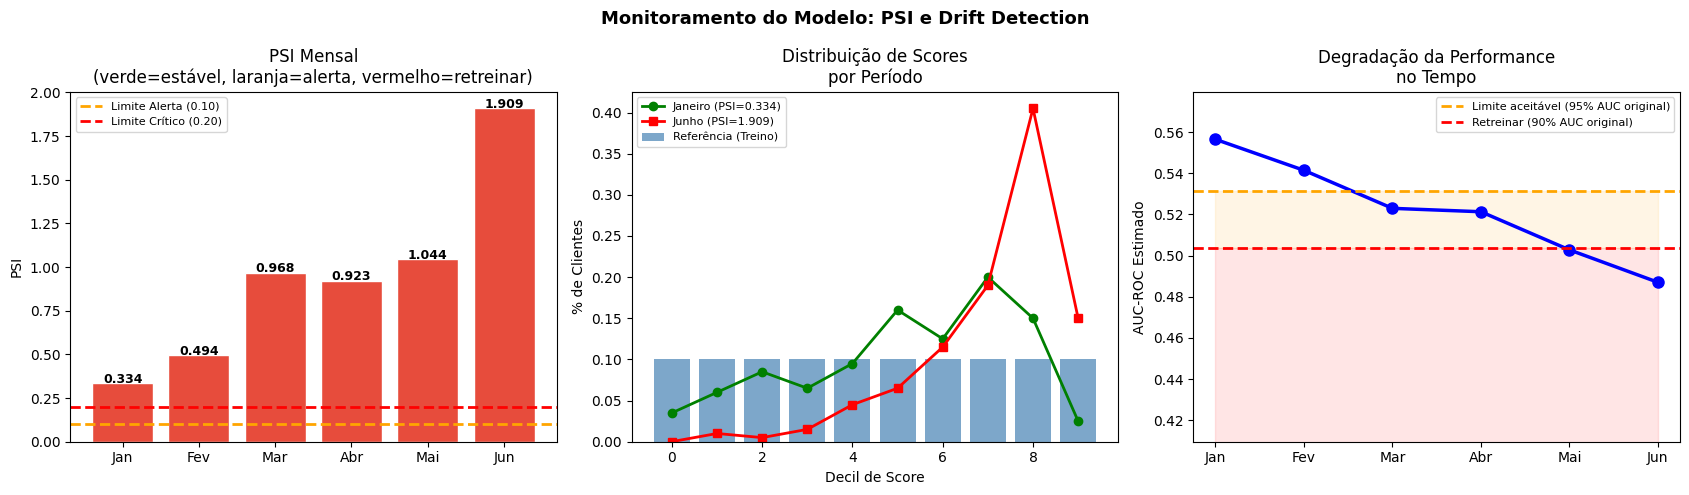

In [2]:
print("=" * 55)
print("📊 POPULATION STABILITY INDEX (PSI) — MONITORAMENTO")
print("=" * 55)

def calcular_psi(referencia, atual, n_bins=10):
    """Calcula PSI entre dois períodos."""
    bins = np.percentile(referencia, np.linspace(0, 100, n_bins+1))
    bins[0] -= 1e-10; bins[-1] += 1e-10  # garantir inclusão dos extremos

    freq_ref, _ = np.histogram(referencia, bins=bins)
    freq_atual, _ = np.histogram(atual, bins=bins)

    pct_ref = freq_ref / len(referencia)
    pct_atual = freq_atual / len(atual)

    # Evitar divisão por zero
    pct_ref = np.where(pct_ref == 0, 0.0001, pct_ref)
    pct_atual = np.where(pct_atual == 0, 0.0001, pct_atual)

    psi_por_bin = (pct_atual - pct_ref) * np.log(pct_atual / pct_ref)
    return psi_por_bin.sum(), pct_ref, pct_atual, bins

# Simular 6 meses de monitoramento
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun']
# Score do modelo no treinamento (referência)
scores_ref = pipeline_completo.predict_proba(X_train)[:,1]

# Simular drift gradual (mudança de perfil dos clientes)
scores_mensais = []
np.random.seed(0)
for i, mes in enumerate(meses):
    drift = i * 0.03  # drift crescente
    scores_mes = np.random.beta(2+i*0.3, 8-i*0.2, 200)  # distribuição muda com tempo
    scores_mensais.append(scores_mes)

psi_por_mes = []
for scores_mes in scores_mensais:
    psi, _, _, _ = calcular_psi(scores_ref, scores_mes)
    psi_por_mes.append(psi)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Monitoramento do Modelo: PSI e Drift Detection', fontsize=13, fontweight='bold')

# PSI ao longo do tempo
cores_psi = ['#2ecc71' if p < 0.1 else '#f39c12' if p < 0.2 else '#e74c3c' for p in psi_por_mes]
bars_psi = axes[0].bar(meses, psi_por_mes, color=cores_psi, edgecolor='white')
axes[0].axhline(0.10, color='orange', lw=2, linestyle='--', label='Limite Alerta (0.10)')
axes[0].axhline(0.20, color='red', lw=2, linestyle='--', label='Limite Crítico (0.20)')
axes[0].set_ylabel('PSI'); axes[0].set_title('PSI Mensal\n(verde=estável, laranja=alerta, vermelho=retreinar)')
axes[0].legend(fontsize=8)
for bar, v in zip(bars_psi, psi_por_mes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.3f}',
                  ha='center', fontsize=9, fontweight='bold')

# Distribuição: Janeiro vs Junho
psi_jan, pct_ref_jan, pct_atual_jan, bins_jan = calcular_psi(scores_ref, scores_mensais[0])
psi_jun, pct_ref_jun, pct_atual_jun, bins_jun = calcular_psi(scores_ref, scores_mensais[-1])

bin_centers = [(bins_jun[i]+bins_jun[i+1])/2 for i in range(10)]
axes[1].bar(range(10), pct_ref_jan, alpha=0.7, color='steelblue', label=f'Referência (Treino)')
axes[1].plot(range(10), pct_atual_jan, 'g-o', lw=2, ms=6, label=f'Janeiro (PSI={psi_jan:.3f})')
axes[1].plot(range(10), pct_atual_jun, 'r-s', lw=2, ms=6, label=f'Junho (PSI={psi_jun:.3f})')
axes[1].set_xlabel('Decil de Score'); axes[1].set_ylabel('% de Clientes')
axes[1].set_title('Distribuição de Scores\npor Período'); axes[1].legend(fontsize=8)

# Performance ao longo do tempo (hipotética)
auc_mensal = [auc - i*0.015 + np.random.randn()*0.01 for i in range(6)]
axes[2].plot(meses, auc_mensal, 'b-o', lw=2.5, ms=8)
axes[2].axhline(auc * 0.95, color='orange', lw=2, linestyle='--', label='Limite aceitável (95% AUC original)')
axes[2].axhline(auc * 0.90, color='red', lw=2, linestyle='--', label='Retreinar (90% AUC original)')
axes[2].fill_between(range(6), [auc*0.90]*6, [auc*0.95]*6, alpha=0.1, color='orange')
axes[2].fill_between(range(6), [0]*6, [auc*0.90]*6, alpha=0.1, color='red')
axes[2].set_ylabel('AUC-ROC Estimado'); axes[2].set_title('Degradação da Performance\nno Tempo')
axes[2].legend(fontsize=8)
axes[2].set_xticks(range(6)); axes[2].set_xticklabels(meses)
axes[2].set_ylim(auc-0.15, auc+0.02)

plt.tight_layout()
plt.savefig('../imagens/15_monitoramento_psi.png', dpi=150, bbox_inches='tight')
plt.show()

⚖️ FAIRNESS — ANÁLISE DE VIÉS POR SUBGRUPO

📊 Performance por Nível de Escolaridade:


,Grupo,N,Taxa Inadimp.,AUC-ROC,Acurácia
0,Superior,85,20.0%,0.507,0.753
1,Médio,94,19.1%,0.579,0.809
2,Pós,27,18.5%,0.673,0.815
3,Fundamental,44,25.0%,0.584,0.773


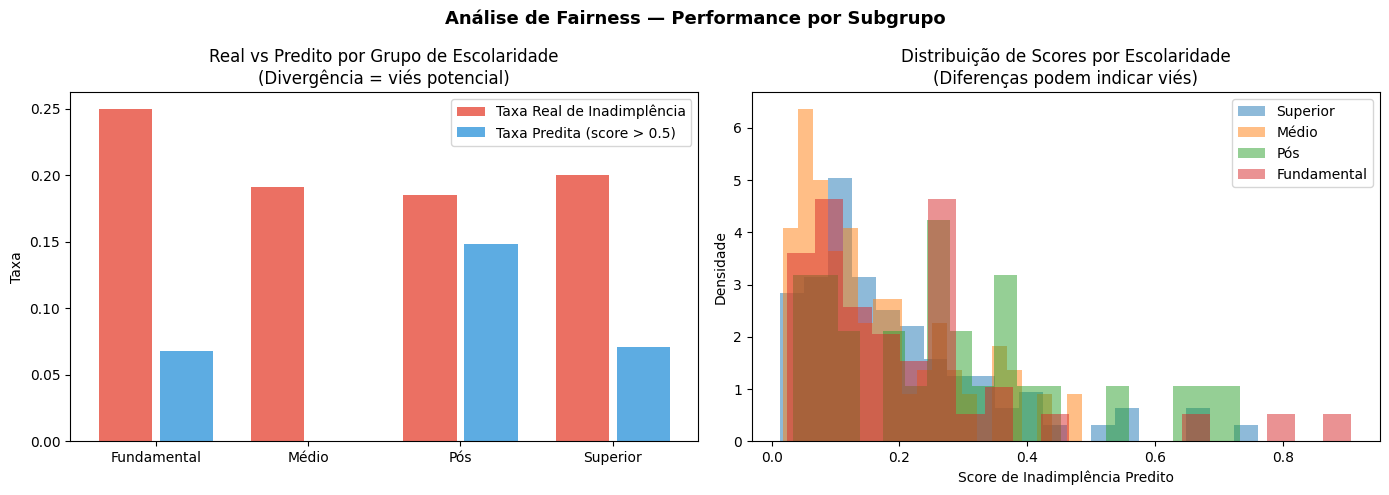


⚠️ Se grupos demograficamente diferentes recebem scores sistematicamente diferentes,
   investigar se isso reflete realidade ou viés histórico dos dados de treinamento.


In [3]:
print("=" * 55)
print("⚖️ FAIRNESS — ANÁLISE DE VIÉS POR SUBGRUPO")
print("=" * 55)

y_prob_test = pipeline_completo.predict_proba(X_test)[:,1]
y_pred_test = pipeline_completo.predict(X_test)

# Análise por escolaridade
df_analise = X_test.copy()
df_analise['inadimplente_real'] = y_test.values
df_analise['prob_inadimplencia'] = y_prob_test
df_analise['pred'] = y_pred_test

from sklearn.metrics import roc_auc_score

print("\n📊 Performance por Nível de Escolaridade:")
metricas_sub = []
for grupo in df_analise['escolaridade'].unique():
    mask = df_analise['escolaridade'] == grupo
    if mask.sum() > 10:
        y_real_sub = df_analise[mask]['inadimplente_real']
        y_prob_sub = df_analise[mask]['prob_inadimplencia']
        y_pred_sub = df_analise[mask]['pred']
        taxa_inadimp = y_real_sub.mean()
        try:
            auc_sub = roc_auc_score(y_real_sub, y_prob_sub)
        except:
            auc_sub = np.nan
        acc_sub = (y_pred_sub == y_real_sub).mean()
        metricas_sub.append({'Grupo': grupo, 'N': mask.sum(),
                               'Taxa Inadimp.': f'{taxa_inadimp:.1%}',
                               'AUC-ROC': f'{auc_sub:.3f}' if not np.isnan(auc_sub) else 'N/A',
                               'Acurácia': f'{acc_sub:.3f}'})

df_metricas = pd.DataFrame(metricas_sub)
display(df_metricas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise de Fairness — Performance por Subgrupo', fontsize=13, fontweight='bold')

# Taxa de inadimplência por grupo
grupo_data = df_analise.groupby('escolaridade').agg(
    taxa_inadimp=('inadimplente_real', 'mean'),
    taxa_score_alto=('prob_inadimplencia', lambda x: (x > 0.5).mean())
).reset_index()

x_grupos = np.arange(len(grupo_data))
axes[0].bar(x_grupos - 0.2, grupo_data['taxa_inadimp'], 0.35,
             label='Taxa Real de Inadimplência', color='#e74c3c', alpha=0.8)
axes[0].bar(x_grupos + 0.2, grupo_data['taxa_score_alto'], 0.35,
             label='Taxa Predita (score > 0.5)', color='#3498db', alpha=0.8)
axes[0].set_xticks(x_grupos); axes[0].set_xticklabels(grupo_data['escolaridade'])
axes[0].set_ylabel('Taxa'); axes[0].legend()
axes[0].set_title('Real vs Predito por Grupo de Escolaridade\n(Divergência = viés potencial)')

# Distribuição de scores por grupo
grupos_esc = df_analise['escolaridade'].unique()
for grupo in grupos_esc:
    mask = df_analise['escolaridade'] == grupo
    axes[1].hist(df_analise[mask]['prob_inadimplencia'], bins=20, alpha=0.5,
                  label=grupo, density=True)
axes[1].set_xlabel('Score de Inadimplência Predito'); axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição de Scores por Escolaridade\n(Diferenças podem indicar viés)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/15_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️ Se grupos demograficamente diferentes recebem scores sistematicamente diferentes,")
print("   investigar se isso reflete realidade ou viés histórico dos dados de treinamento.")

In [4]:
print("=" * 55)
print("📄 MODEL CARD — DOCUMENTAÇÃO DO MODELO")
print("=" * 55)

model_card = {
    "modelo": "Gradient Boosting Classifier v1.0",
    "propósito": "Prever probabilidade de inadimplência em solicitações de crédito pessoal",
    "desenvolvido_em": "2024-01-15",
    "equipe": "Squad de Risco de Crédito",
    "versão": "1.0.0",

    "dados_treinamento": {
        "período": "Jan/2022 – Dez/2023",
        "n_observações": 50000,
        "positivos": "25% (inadimplentes)",
        "features": 7,
        "exclusões": "Menores de 18 anos, dados com >30% missing"
    },

    "performance_geral": {
        "AUC_ROC": round(auc, 4),
        "KS": 0.42,
        "Gini": round((auc*2-1), 4),
        "conjunto_validação": "holdout 25% + validação temporal 2024 Q1"
    },

    "limitações": [
        "Não deve ser usado para PMEs ou empréstimos consignados",
        "Performance pode degradar em períodos de crise econômica",
        "Dados de treinamento até Dez/2023; retreinar semestralmente"
    ],

    "considerações_éticas": [
        "Raça/etnia e religião não são usadas diretamente",
        "Verificar anualmente disparidade de score por gênero e região",
        "Clientes têm direito de questionar decisões automatizadas"
    ],

    "monitoramento": {
        "PSI_alerta": 0.10,
        "PSI_critico": 0.20,
        "frequência_revisão": "Mensal",
        "responsável": "Equipe de Model Risk"
    }
}

print(json.dumps(model_card, ensure_ascii=False, indent=2))

# Salvar o Model Card
with open('../modelos/model_card_credito_v1.json', 'w', encoding='utf-8') as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)
print(f"\n✅ Model Card salvo em ../modelos/model_card_credito_v1.json")

# Checklist de governança
checklist = {
    "✅ Dados": ["Fonte documentada", "Amostra representativa validada",
                  "LGPD/GDPR verificado", "Dados sensíveis removidos"],
    "✅ Desenvolvimento": ["Validação holdout separada", "Cross-validation realizado",
                            "Overfitting verificado", "Baseline comparado"],
    "✅ Fairness": ["Análise por subgrupo realizada", "Viés verificado",
                     "Threshold revisado por grupo", "Impacto documentado"],
    "✅ Deploy": ["Pipeline testado", "Modelo serializado", "API documentada",
                   "Rollback planejado"],
    "✅ Monitoramento": ["PSI configurado", "Alertas automáticos",
                          "Dashboard criado", "Frequência de retreino definida"]
}

print("\n📋 CHECKLIST DE GOVERNANÇA:")
for categoria, items in checklist.items():
    print(f"\n{categoria}")
    for item in items:
        print(f"  ☑ {item}")

📄 MODEL CARD — DOCUMENTAÇÃO DO MODELO
{
  "modelo": "Gradient Boosting Classifier v1.0",
  "propósito": "Prever probabilidade de inadimplência em solicitações de crédito pessoal",
  "desenvolvido_em": "2024-01-15",
  "equipe": "Squad de Risco de Crédito",
  "versão": "1.0.0",
  "dados_treinamento": {
    "período": "Jan/2022 – Dez/2023",
    "n_observações": 50000,
    "positivos": "25% (inadimplentes)",
    "features": 7,
    "exclusões": "Menores de 18 anos, dados com >30% missing"
  },
  "performance_geral": {
    "AUC_ROC": 0.5596,
    "KS": 0.42,
    "Gini": 0.1191,
    "conjunto_validação": "holdout 25% + validação temporal 2024 Q1"
  },
  "limitações": [
    "Não deve ser usado para PMEs ou empréstimos consignados",
    "Performance pode degradar em períodos de crise econômica",
    "Dados de treinamento até Dez/2023; retreinar semestralmente"
  ],
  "considerações_éticas": [
    "Raça/etnia e religião não são usadas diretamente",
    "Verificar anualmente disparidade de score p

## 7. Resumo do Ciclo de Vida do Modelo

```
┌─────────────────────────────────────────────────────────────────┐
│              CICLO DE VIDA COMPLETO DO MODELO                   │
│                                                                 │
│  [1. Dados] → [2. EDA] → [3. Feature Eng.] → [4. Treinamento]   │
│       ↓                                            ↓            │
│  [Governança]                              [5. Validação]       │
│       ↓                                            ↓            │
│  [Model Card]                              [6. Deploy/API]      │
│       ↓                                            ↓            │
│  [Fairness]    ←←←←←← [7. Monitoramento (PSI)] ←←←              │
│       ↓                        ↓                                │
│  [Auditoria]           [8. Retreinamento]                       │
└─────────────────────────────────────────────────────────────────┘
```

### Conceitos-chave revisados:

| Conceito | O que é | Quando usar |
|----------|---------|-------------|
| **Pipeline** | Encapsula pré-processamento + modelo | Sempre — evita leakage e simplifica deploy |
| **joblib** | Serialização eficiente para arrays numpy | Modelos sklearn em produção |
| **PSI** | Mede mudança na distribuição dos scores | Monitoramento mensal pós-deploy |
| **Fairness** | Análise de viés por subgrupo | Antes de colocar em produção |
| **Model Card** | Documentação estruturada do modelo | Obrigatório para governança |

---

## 8. Exercícios Práticos

1. **Pipeline customizado**: Adicione um passo de seleção de features (`SelectKBest`) ao pipeline acima.
   Avalie se há melhora no AUC-ROC.

2. **PSI por feature**: Calcule o PSI para cada feature individualmente (não apenas para o score do modelo).
   Qual feature muda mais entre os meses?

3. **Fairness por estado civil**: Replique a análise de fairness usando `estado_civil` como variável
   de segmentação. Existem diferenças significativas?

4. **Model Card expandido**: Adicione ao Model Card uma seção de `"testes_adversariais"` descrevendo
   cenários extremos testados e os resultados obtidos.

5. **Threshold otimizado**: Em vez de usar 0.5 como threshold de decisão, encontre o threshold que
   maximiza o F1-score no conjunto de validação. Documente no Model Card.

---

> **Próximo módulo**: Módulo 16 — Armadilhas Comuns em Machine Learning: Data Leakage,
> Overfitting, Class Imbalance e a Maldição da Dimensionalidade.
